# Лабораторная работа 1. Numpy


Версия от 12.09

## Задание 1. Многорукий бандит

Задание суммарно оценивается в 1 балл.


### Постановка задачи о многоруком бандите

Когда-то давно были популярны игровые автоматы, которыми управляли при помощи ручек. Эти автоматы получили прозвище «бандиты», потому что после общения с ними люди обычно чувствовали себя ограбленными. Математики построили математическую модель такого автомата. Так возникла формальная **задача многорукого бандита**. Эта модель активно применяется при построении рекомендательных систем. В качестве ручек рассматриваются фильмы или товары. Если пользователь просмотрел предложение - значит, "мы выиграли" и рекомендация подошла.

Представьте, что вы находитесь в казино перед несколькими игровыми автоматами, и каждый из них настроен с неизвестной вероятностью того, что вы можете получить вознаграждение за одну игру. Возникает вопрос: какова наилучшая стратегия, чтобы получить максимальный выигрыш при условии, что вы не знаете вероятности?

Построим следующую математическую модель. Будем считать, что каждая ручка выдаёт награду 1 с некоторой неизвестной вероятностью $p$, то есть приблизим ручку бернуллиевским распределением $Bern(p)$, которое с течением времени не меняется.

Более формально

- У нас есть $k$ ручек с неизвестными вероятностями "выигрыша" $(\theta_1, \theta_2, \dots, \theta_k)$.
- В каждый момент времени $t$ мы дергаем за одну из ручек и получаем какой-то выигрыш $r_t$ (он может быть равен 0).
- $A$ - множество действий, которые мы предприняли (каждое действие - взаимодействие с одной из ручек бандита). В результате каждого действия $a_i$ мы получаем выигрыш $Q(a_i)$, $E(Q(a_i))=\theta_i$.
- $R$ - функция выигрыша. В нашем случае в каждый момент времени $t$ выигрыш $R(t,Q(a_t))$ равен 1, если мы выиграли, и это произойдет с вероятностью $\theta_i$, или равен 0, если мы проиграли, и это произойдет с вероятностью $1-\theta_i$.

Чтобы решить задачу, нам нужно максимизировать общий выигрыш $\sum r_t$.

В нашем случае достаточно найти лучшую ручку, то есть максимальную вероятность $\theta*$.

При этом функция потерь $L_t = E(\sum_{i=1}^{t}(\theta* - Q(a_t))$


**Упражнение 0:**

Импортируйте NumPy как `np`. Выясните, какая версия NumPy у вас установлена (погуглите, как. есть способ, работающий для любого пакета).

In [4]:
import numpy as np
import matplotlib.pyplot as plt

print(np.__version__)

2.1.1


Для начала создадим базовый класс для многорукого бандита. В нем будет конструктор и функция генерации наград сразу для всех ручек бандита.

In [12]:
class MultiarmedBandit():
    def __init__(self, k):
        '''
        Параметры
        k - число ручек
        ...
        '''
        self.k = k


    def generate_reward():
        '''
        Генерация наград для всех ручек сразу
        Выдаётся вектор сгенерированных наград
        '''
        pass

Также создадим класс для алгоритмов, которые будут играть с нашим бандитом. Алгоритм должен уметь предсказывать, какую ручку выбрать следующей. Также при вызове update() алгоритм будет обновлять свои внутренние параметры.

In [13]:
class Algorithm():
    def __init__(self, k):
        pass

    def predict(self):
        '''
        Предсказать лучшее действие
        '''
        pass

    def update(self, action, reward):
        '''
        Обновить внутренние параметры
        '''
        pass

### Бернуллиевский бандит

Этот бандит - один из простейший. На каждом шаге он генерирует награду каждой ручки из бернуллиевского распределения с заданным параметром.

In [14]:
# 0.2 балла
class BernoulliBandit(MultiarmedBandit):
    def __init__(self, k, probas):
        '''
        Добавьте в конструктор параметры
        k - число ручек
        probas - вероятности генерации наград
        '''
        super().__init__(k)
        self.probas = np.array(probas)

    def generate_reward(self):
        '''
        Генерация наград для всех ручек сразу
        Выдаётся вектор длины k со сгенерированными наградами
        '''
        return np.random.binomial(1, self.probas)

### Стратегии решения

#### $\epsilon$-greedy

Совсем жадный алгоритм, который выбирает на каждом шаге лучшую ручку, в общем случае будет работать плохо. Сделаем небольшую модернизацию: с вероятностью $1-\epsilon$ будем выбирать текущую лучшую ручку, а с вероятностью $\epsilon$ - какую-то произвольную ручку.

Ценность каждого действия оценивается путем усреднения вознаграждений, связанных с целевым действием a, которые мы наблюдали до текущего временного шага t:

$$\hat Q_t(a) = \dfrac{1}{N_t(a)}\sum^t_{i = 1}r_i I[a_i==a]$$

Здесь $I$ - индикаторная функция, равная 1, если внутри истинное утверждение и 0, если ложное. $N_t(a)$ - количество раз, в которых было выбрано действие $a$.

In [15]:
# 0.2 балла
class EGreedyAlgorithm(Algorithm):
    def __init__(self, k, eps, initial_proba=1.0):
        # параметры - эпсилон и начальные оценки вероятности Q для каждой ручки
        # добавьте k - число ручек
        super().__init__(k)
        self.eps = eps
        self.k = k
        self.counts = np.zeros(k)
        self.estimates = np.full(k, initial_proba)

    @property
    def estimated_probas(self):
        # возвращаем текущие оценки вероятностей
        return self.estimates

    def predict(self):
        # что выбрать?
        if np.random.rand() < self.eps:
            return np.random.randint(self.k)
        else:
            return np.argmax(self.estimates)

    def update(self, action, reward):
        # обновляемся! не забудьте добавить в параметры результат взаимодействия
        self.counts[action] += 1
        alpha = 1 / self.counts[action]
        self.estimates[action] += alpha * (reward - self.estimates[action])

####  Сэмплирование Томпсона

Сэмплирование Томпсона (иногда его называют алгоритмом байесовых бандитов) работает иначе: вместо уточнения прогноза среднего вознаграждения она расширяет его, чтобы построить вероятностную модель из полученных вознаграждений, а затем выбрать на её основе действие.

Итак, при сэмплировании Томпсона получается модель вероятностей вознаграждения. Когда доступность вознаграждения является бинарной (как в этом случае, да или нет), идеальной моделью для такой вероятности является бета-распределение.

Бета-распределение зависит от двух параметров: $\alpha$ и $\beta$. Проще говоря, это счётчики числа успехов и неудач. Также у бета-распределения есть усреднённое значение, вычисляемое как:

$\frac{\alpha}{\alpha + \beta} = \frac{number-of-successes}{number-of-trials}$

Если мы выиграли, то вознаграждение равно 1, и $\alpha$ — счётчик успехов — увеличивается на 1. $\beta$ - счётчик неудач — не растёт. Если же мы не получим вознаграждение, то $\alpha$ не изменится, а $\beta$ увеличится на 1. Чем больше мы собираем данных, тем сильнее бета-распределение начинает отличаться от прямой линии и становится всё более точной моделью вероятности усреднённого вознаграждения. Поддерживая значения $\alpha$ и $\beta$, алгоритм сэмплирования Томпсона может описать ожидаемое среднее вознаграждение и уровень его достоверности.

Итого, в каждый момент времени мы сэмплируем ожидаемый выигрыш $\hat Q_t(a)$ из априорного бета-распределения $Beta(\alpha_i,\beta_i)$ для каждого действия. Лучшее действие выбирается среди вариантов $a^{TS}_t = argmax_{a \in A}\hat Q(a)$. Затем мы получаем истинное значение выигрыша, и можем соответствующим образом обновить бета-распределение.

$\alpha_i \leftarrow \alpha_i + r_t[a^{TS}_t==a]$

$\beta_i \leftarrow \beta_i + (1-r_t)[a^{TS}_t==a]$

Получаемые нами оценки вознаграждения $\hat Q(a)$ сэмплируются из апостериорных распределений, каждая из получаемых вероятностей эквивалентна вероятности того, что соответствующее действие является оптимальным при условии наблюдаемой истории :)


In [16]:
# 0.3 балла
class ThompsonSamplingAlgorithm(Algorithm):
    def __init__(self, k, init_a=1, init_b=1):
        # начальные значение параметров бандита
        # для оценок используются два вектора параметров - альфы и беты
        # все оценки инициализируются одинаково
        # добавьте k - число ручек
        super().__init__(k)
        self.k = k
        self.alphas = np.full(k, init_a)
        self.betas = np.full(k, init_b)

    @property
    def estimated_probas(self):
        return self.alphas / (self.alphas + self.betas)

    def predict(self):
        samples = np.random.beta(self.alphas, self.betas)
        return np.argmax(samples)

    def update(self, action, reward):
        self.alphas[action] += reward  # α_i ← α_i + r_t[a_t == a]
        self.betas[action] += 1 - reward  # β_i ← β_i + (1 - r_t)[a_t == a]

### Эксперимент

Запустите ваши алгоритмы на бернулиевском бандите с какими-нибудь фиксированными вероятностями получения награды и сравните результаты. Можете использовать предложенный ниже код.

In [17]:
# взаимодействие бандита и алгоритма
# 0.1 балла

k = 5
true_probas = [0.1, 0.3, 0.5, 0.7, 0.9]
bandit = BernoulliBandit(k, true_probas)
algorithm = EGreedyAlgorithm(k, eps=0.1, initial_proba=1.0)

num_steps = 1000

# сначала заводим вектор rewards для хранения наград
rewards = []
actions_list = []

for t in range(num_steps):
    # новые действия
    actions = algorithm.predict()
    # собираем все действия - для отладки в случае странностей
    actions_list.append(actions)

    # вектор всех наград
    action_rewards = bandit.generate_reward()

    # обновление параметров
    algorithm.update(actions, action_rewards[actions])

    # сохраняем награды
    rewards.append(action_rewards[actions])


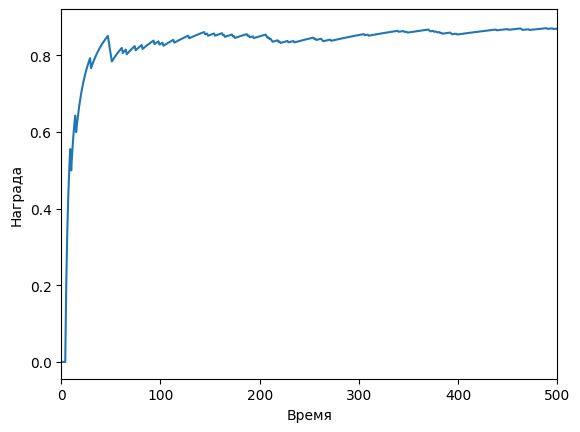

In [24]:
# небольшая визуализация
# 0.2 балла

import matplotlib.pyplot as plt

times = np.arange(1, num_steps + 1)
cumulative_rewards = np.cumsum(rewards)
mean_rewards = cumulative_rewards / times

plt.figure()
plt.plot(times, mean_rewards)  # рисуем время и среднюю награду на отрезке времени от 0 до текущего
plt.xlabel('Время')
plt.ylabel('Награда')
plt.xlim(0, 500)
plt.show()


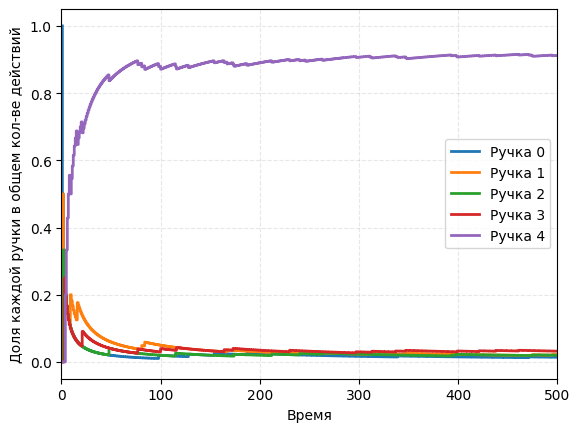

In [25]:

# Рисуем, какую долю всех выборов на текущем шаге занимает выбор конкретной ручки
arms = np.arange(k)
arm_counts_over_time = np.zeros((num_steps, k))
counts = np.zeros(k)

for t in range(num_steps):
    action = actions_list[t]
    counts[action] += 1
    arm_counts_over_time[t] = counts.copy()

arm_percent_over_time = arm_counts_over_time / times[:, np.newaxis]

plt.figure()
for arm in arms:
    plt.plot(times, arm_percent_over_time[:, arm], ds='steps', lw=2, label=f'Ручка {arm}')  # рисуем долю каждой ручки
plt.xlabel('Время')
plt.ylabel('Доля каждой ручки в общем кол-ве действий')
plt.legend()
plt.xlim(0, 500)
plt.grid('k', ls='--', alpha=0.3)
plt.show()

Всё так и есть, ручка 4 - выигрышная!

## Задание 2. Разные задачи

Этот раздел суммарно оценивается в 1 балл. Каждая задача оценивается в 0.125 балла.


**Упражнение 1**

Выполните следующие действия, используя функциональность numpy.
- создайте три массива - из нулей, единиц и двоек, размера 5 на 6 на 20,
- создайте массив из единиц размера 3 на 10, посчитайте его сумму,
- создайте единичную матрицу 6 на 6, прибавьте к ней матрицу такого же размера с числами от 1 до 6 на диагонали, посчитайте определитель,
- создайте массив 100 на 10 из случайных чисел из нормального распределения с математическим ожиданием 2 и дисперсией 4, посчитайте математическое ожидание и дисперсию для всего массива
- создайте матрицу, у которой на главной диагонали стоят числа 3, 1, 4, 1, 5, 9, 2, 6, и транспонируйте её.


In [ ]:
import numpy as np

zeros_array = np.zeros((5, 6, 20))
ones_array = np.ones((5, 6, 20))
twos_array = np.full((5, 6, 20), 2)

array_ones = np.ones((3, 10))
sum_array_ones = np.sum(array_ones)
print("Сумма массива из единиц:", sum_array_ones)

identity_matrix = np.eye(6)
diagonal_matrix = np.diag(np.arange(1, 7))
sum_matrix = identity_matrix + diagonal_matrix
determinant = np.linalg.det(sum_matrix)
print("Определитель матрицы:", determinant)

mean = 2
variance = 4
std_dev = np.sqrt(variance)
random_array = np.random.normal(mean, std_dev, (100, 10))
array_mean = np.mean(random_array)
array_variance = np.var(random_array)
print("Математическое ожидание массива:", array_mean)
print("Дисперсия массива:", array_variance)

diag_elements = [3, 1, 4, 1, 5, 9, 2, 6]
matrix = np.diag(diag_elements)
matrix[1][3] = 69
matrix[3][7] = 69
matrix[6][4] = 96
matrix[7][3] = 96
transposed_matrix = matrix.T
print("Исходная матрица:\n", matrix)
print("Транспонированная матрица:\n", transposed_matrix)


Сумма массива из единиц: 30.0
Определитель матрицы: 5040.000000000002
Математическое ожидание массива: 2.146713828136423
Дисперсия массива: 4.080683037643631
Исходная матрица:
 [[ 3  0  0  0  0  0  0  0]
 [ 0  1  0 69  0  0  0  0]
 [ 0  0  4  0  0  0  0  0]
 [ 0  0  0  1  0  0  0 69]
 [ 0  0  0  0  5  0  0  0]
 [ 0  0  0  0  0  9  0  0]
 [ 0  0  0  0 96  0  2  0]
 [ 0  0  0 96  0  0  0  6]]
Транспонированная матрица:
 [[ 3  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0]
 [ 0  0  4  0  0  0  0  0]
 [ 0 69  0  1  0  0  0 96]
 [ 0  0  0  0  5  0 96  0]
 [ 0  0  0  0  0  9  0  0]
 [ 0  0  0  0  0  0  2  0]
 [ 0  0  0 69  0  0  0  6]]


**Упражнение 2**

Создайте массив `a` случайных чисел `np.random.randn()` размеров (10,10,10). Для каждого двумерного среза с одной фиксированной координатой (0й, 1й и 2й) найти
- наибольший и наименьший элемент.
- сумму всех положительных элементов.  
- среднее значение и среднеквадратичное отклонение.
- медиану.

In [ ]:
import numpy as np

a = np.random.randn(10, 10, 10)

for axis in range(3):
    print(f"\nСтатистика по оси {axis}:")
    for index in range(a.shape[axis]):
        if axis == 0:
            slice_2d = a[index, :, :]
        elif axis == 1:
            slice_2d = a[:, index, :]
        else:
            slice_2d = a[:, :, index]
        max_elem = np.max(slice_2d)
        min_elem = np.min(slice_2d)
        sum_positive = np.sum(slice_2d[slice_2d > 0])
        mean_val = np.mean(slice_2d)
        std_dev = np.std(slice_2d)
        median_val = np.median(slice_2d)
        print(f"Срез {index}: макс={max_elem:.3f}, мин={min_elem:.3f}, \
        сумма+={sum_positive:.3f}, среднее={mean_val:.3f}, σ={std_dev:.3f}, медиана={median_val:.3f}")



Статистика по оси 0:
Срез 0: макс=2.564, мин=-2.261,         сумма+=46.389, среднее=0.151, σ=0.952, медиана=0.117
Срез 1: макс=3.017, мин=-2.138,         сумма+=35.095, среднее=-0.082, σ=0.991, медиана=-0.184
Срез 2: макс=3.393, мин=-2.642,         сумма+=40.554, среднее=-0.051, σ=1.103, медиана=-0.033
Срез 3: макс=2.150, мин=-2.095,         сумма+=41.035, среднее=0.054, σ=0.945, медиана=0.029
Срез 4: макс=2.707, мин=-1.952,         сумма+=45.075, среднее=0.104, σ=0.966, медиана=0.251
Срез 5: макс=2.695, мин=-2.249,         сумма+=38.489, среднее=0.012, σ=0.968, медиана=-0.027
Срез 6: макс=1.970, мин=-2.267,         сумма+=40.971, среднее=-0.042, σ=1.041, медиана=-0.062
Срез 7: макс=2.505, мин=-2.425,         сумма+=45.127, среднее=0.147, σ=0.932, медиана=0.109
Срез 8: макс=2.601, мин=-2.868,         сумма+=37.682, среднее=-0.149, σ=1.095, медиана=-0.190
Срез 9: макс=2.086, мин=-2.203,         сумма+=36.026, среднее=-0.057, σ=0.934, медиана=0.061

Статистика по оси 1:
Срез 0: макс=2.2

**Упражнение 3**

Создайте массив `a` из 10 случайных чисел (float-ов).

Оцените, насколько "экономнее" хранить его как NumPy-массив (а не как `list(a)`). Для этого сгенерируйте массив `a` из 10, 100, ..., $10^6$ таких случайных чисел и вычислите долю размера `a` от размера `list(a)`.

_Размер в памяти какого-то обьекта в Python можно определить функцией из библиотеки `sys` – системных утилит._

In [ ]:
import numpy as np
import sys

elements = [10, 100, 1000, 10000, 100000, 1000000]
ratios = []

size_of_float = sys.getsizeof(float())

for n in elements:
    np_a = np.random.rand(n)
    list_a = list(np_a)

    size_np_array = a.nbytes + sys.getsizeof(np_a)
    size_list = sys.getsizeof(list_a) + n * size_of_float

    ratio = size_np_array / size_list
    ratios.append(ratio)
    print(f"n={n:<10} размер NumPy массива={size_np_array:<20} "
    f"размер списка={size_list:<15} отношение={ratio:<10.4f}")



n=10         размер NumPy массива=8192                 размер списка=376             отношение=21.7872   
n=100        размер NumPy массива=8912                 размер списка=3256            отношение=2.7371    
n=1000       размер NumPy массива=16112                размер списка=32056           отношение=0.5026    
n=10000      размер NumPy массива=88112                размер списка=320056          отношение=0.2753    
n=100000     размер NumPy массива=808112               размер списка=3200056         отношение=0.2525    
n=1000000    размер NumPy массива=8008112              размер списка=32000056        отношение=0.2503    


**Упражнение 4**

Давайте исследуем механизм broadcasting.

Попробуйте сложить значения пар массивов следующих размеров

- 4x3x5 и 3x5
- 4x3x5 и 4x5
- 4x3x5 и 5
- 4x3x5 и 4
- 4 и 4x3x5

Когда механизм срабатывает, а когда - нет?

Исправьте размеры массивов так, чтобы механизм срабатывал.

In [ ]:
import numpy as np

A = np.random.rand(4, 3, 5)
B = np.random.rand(3, 5)

try:
    result = A + B
    print("Сложение (4,3,5) и (3,5) успешно.")
except ValueError as e:
    print("Ошибка при сложении (4,3,5) и (3,5):", e)

B = np.random.rand(4, 5)
try:
    result = A + B
    print("Сложение (4,3,5) и (4,5) успешно.")
except ValueError as e:
    print("Ошибка при сложении (4,3,5) и (4,5):", e)

B = np.random.rand(5)
try:
    result = A + B
    print("Сложение (4,3,5) и (5) успешно.")
except ValueError as e:
    print("Ошибка при сложении (4,3,5) и (5):", e)

B = np.random.rand(4)
try:
    result = A + B
    print("Сложение (4,3,5) и (4) успешно.")
except ValueError as e:
    print("Ошибка при сложении (4,3,5) и (4):", e)

A = np.random.rand(4)
B = np.random.rand(4, 3, 5)
try:
    result = A + B
    print("Сложение (4) и (4,3,5) успешно.")
except ValueError as e:
    print("Ошибка при сложении (4) и (4,3,5):", e)


Сложение (4,3,5) и (3,5) успешно.
Ошибка при сложении (4,3,5) и (4,5): operands could not be broadcast together with shapes (4,3,5) (4,5) 
Сложение (4,3,5) и (5) успешно.
Ошибка при сложении (4,3,5) и (4): operands could not be broadcast together with shapes (4,3,5) (4,) 
Ошибка при сложении (4) и (4,3,5): operands could not be broadcast together with shapes (4,) (4,3,5) 


При выполнении операций над массивами NumPy сравнивает их размеры по каждому измерению, начиная с последнего (справа налево).
Два измерения совместимы, если они равны или одно из них равно 1.
Если размеры по какому-либо измерению не совместимы, возникает ошибка.

In [ ]:
import numpy as np

# b) (4,3,5) и (4,5)
A = np.random.rand(4, 3, 5)
B = np.random.rand(4, 5)
B = B.reshape(4, 1, 5)
result = A + B

# d) (4,3,5) и (4)
B = np.random.rand(4)
B = B[:, np.newaxis, np.newaxis]  # Форма (4,1,1)
result = A + B

# e) (4) и (4,3,5)
A = np.random.rand(4)
A = A[:, np.newaxis, np.newaxis]
B = np.random.rand(4, 3, 5)
result = A + B


**Упражнение 5**

Создайте массив случайных чисел из стандартного нормального распределения размера 100. Замените отрицательные числа в этом массиве на нули, используя а) булевскую маску, б) np.where. Затем получите из матрицы две квадратные, используя два разных вида развертывания (C и F). Затем разверните первую матрицу обратно в одномерный массив.

In [ ]:
import numpy as np

arr = np.random.randn(100)

arr_masked = arr.copy()
arr_masked[arr_masked < 0] = 0

arr_where = np.where(arr < 0, 0, arr)

matrix_C = arr_masked.reshape((10, 10), order='C')
matrix_F = arr_masked.reshape((10, 10), order='F')

flattened_array = matrix_C.flatten(order='C')

**Упражнение 6**

Создайте 4 матрицы
- A из единиц, размера 3 на 4,
- В из нулей, размера 5 на 4,
- C - "шахматную" из нулей и единиц, размера 4 на 3, первое значение 0,
- D из чисел от 1 до 12, записанных в виде змейки, размера 4 на 3.

Создайте из этих матриц "лоскутную" матрицу

A C

B D

используя только стандартные операции numpy. Comprehensions использовать нельзя.

In [ ]:
import numpy as np

A = np.ones((3, 4))
B = np.zeros((5, 4))

left_block = np.vstack((A, B))

C = np.zeros((4, 3), dtype=int)
C[::2, 1::2] = 1
C[1::2, ::2] = 1

D = np.arange(1, 13).reshape(4, 3)
D[1::2] = D[1::2, ::-1]

right_block = np.vstack((C, D))

patchwork = np.hstack((left_block, right_block))

print("Лоскутная матрица:\n", patchwork)


Лоскутная матрица:
 [[ 1.  1.  1.  1.  0.  1.  0.]
 [ 1.  1.  1.  1.  1.  0.  1.]
 [ 1.  1.  1.  1.  0.  1.  0.]
 [ 0.  0.  0.  0.  1.  0.  1.]
 [ 0.  0.  0.  0.  1.  2.  3.]
 [ 0.  0.  0.  0.  6.  5.  4.]
 [ 0.  0.  0.  0.  7.  8.  9.]
 [ 0.  0.  0.  0. 12. 11. 10.]]


**Упражнение 7**

Создайте массив случайных чисел длины 50. Используйте равномерное распределение на отрезке от нуля до единицы.

Далее, создайте массив случайных целых чисел такого же размера. Отсортируйте первый массив, используя значения из второго как ключи. Используйте сортировку и лямбда-функцию.

Далее, сделайте из этого массива массив ширины 5, а затем измените его тип на целочисленный.


In [ ]:
import numpy as np

A = np.random.uniform(0, 1, 50)
B = np.random.randint(0, 100, 50)

sorted_indices = np.argsort(B)
A_sorted = A[sorted_indices]
A_reshaped = A_sorted.reshape(-1, 5)
A_int = (A_reshaped * 100).astype(int)

print("Итоговый массив:\n", A_int)

Итоговый массив:
 [[90 25 40 95 58]
 [69 77 50  6 85]
 [65  0 16 79 46]
 [52 70 18 31 66]
 [17 11 89 36 99]
 [26 55 42 47 78]
 [99 43 73 38 80]
 [34 26 78 59 14]
 [68 65 51  2  9]
 [85 19 87 44 64]]


**Упражнение 8**

_**(Сначала пара подсказок)**_

_Вот так можно отобразить элементы матрицы. Цветовую схему я выбрал оттенки серого, т.к значения тут все положительные._



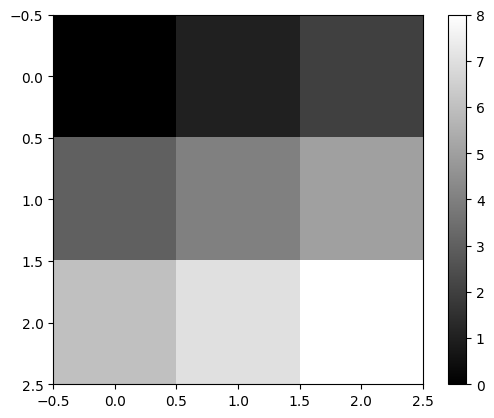

In [ ]:
a = np.arange(9).reshape(3,3)

plt.imshow(a, cmap = 'gray')
plt.colorbar()

_Допустим, вы хотите построить вот такой "график" (вид сверху, интенсивность серого кодирует высоту графика) функции от двух переменных, $x$ и $y$. Вы хотите, чтобы $x$ и $y$ принимали значения от $0$ до $1$, и вам достаточно в этом интервале вычислить функцию в 100 точках (10 шагов по $x$, 10 шагов по $y$, итого шаг решетки – $0.1$). Вот, как это можно сделать (командой `np.meshgrid()`):_

In [ ]:
ps = np.arange(0,1,0.1)

xs, ys = np.meshgrid(ps,ps)

In [ ]:
print(xs)
print(ys)

[[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]]
[[0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
 [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]
 [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7]
 [0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8]
 [0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9]]


_(Посмотрите, как выглядят массивы `xs` и `ys`)_

**_Теперь задание:_**
Постройте вот такой "двумерный" график в оттенках серого функции $I(x,y)$ (I for intensity) расстояния от центра координат

$$I = \sqrt{x^2 + y^2}$$

Для $(x,y)$ от $-1$ до $1$, с шагом 0.05.

Покажите на этом графике область, где $I < 0.5$

_(Если интенсивность идет от белого к черному с возрастанием значения – поменяйте знак всего массива интенсивностей, чтобы область $I < 0.5$ была окрашена оттенками серого, а внешняя часть – была белой_

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-1, 1.05, 0.05)
y = np.arange(-1, 1.05, 0.05)
xs, ys = np.meshgrid(x, y)
I = np.sqrt(xs**2 + ys**2)
I_norm = I / np.max(I)
I_display = I_norm
I_display[I_norm >= 0.5] = 0

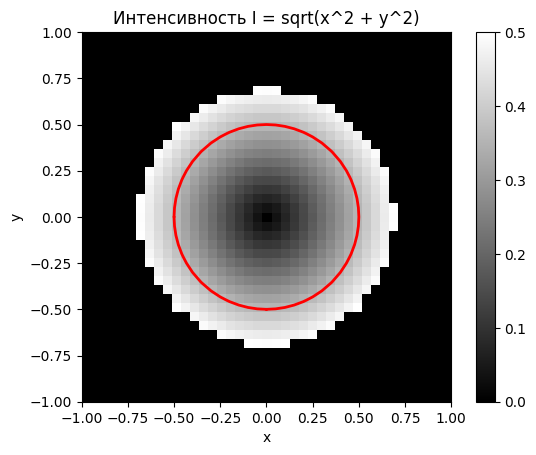

In [ ]:
im = plt.imshow(I_display, cmap='gray', extent=[-1, 1, -1, 1], origin='lower')
contour = plt.contour(xs, ys, I, levels=[0.5], colors='red', linewidths=2)

plt.colorbar(im)
plt.title('Интенсивность I = sqrt(x^2 + y^2)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()